DATA SCIENCE

In [ ]:
# Online_Learning_Behavior_Dataset_Worldwide.csv

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online_Learning_Behavior_Dataset_Worldwide.csv to Online_Learning_Behavior_Dataset_Worldwide.csv


In [6]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
df = pd.read_csv('Online_Learning_Behavior_Dataset_Worldwide.csv')

In [9]:
df.head()

,Student_ID,Country,Age,Gender,Education_Level,Field_of_Study,Platform_Used,Device_Used,Learning_Mode,Enrollment_Date,Daily_Learning_Hours,Quizzes_Attempted,Assignments_Submitted,Course_Completion_Rate(%),Satisfaction_Score(1-5)
0,1,South Africa,21,Other,High School,Medicine,Khan Academy,Mobile,Self-Paced,2023-11-24,4.58,7,3,28.91,2
1,2,South Africa,49,Female,Undergraduate,Arts,Udacity,Tablet,Self-Paced,2023-02-17,3.28,0,8,37.49,2
2,3,UK,20,Female,High School,Engineering,edX,Tablet,Self-Paced,2023-03-23,2.37,4,3,75.85,3
3,4,France,38,Other,Undergraduate,Data Science,Coursera,Mobile,Hybrid,2023-08-24,5.85,12,1,62.90,5
4,5,France,44,Other,Postgraduate,Business,edX,Tablet,Self-Paced,2023-04-27,5.92,7,1,81.85,4


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 1000 non-null   int64  
 1   Country                    1000 non-null   object 
 2   Age                        1000 non-null   int64  
 3   Gender                     1000 non-null   object 
 4   Education_Level            1000 non-null   object 
 5   Field_of_Study             1000 non-null   object 
 6   Platform_Used              1000 non-null   object 
 7   Device_Used                1000 non-null   object 
 8   Learning_Mode              1000 non-null   object 
 9   Enrollment_Date            1000 non-null   object 
 10  Daily_Learning_Hours       1000 non-null   float64
 11  Quizzes_Attempted          1000 non-null   int64  
 12  Assignments_Submitted      1000 non-null   int64  
 13  Course_Completion_Rate(%)  1000 non-null   float6

In [12]:
df.notnull().sum()

,0
Student_ID,1000
Country,1000
Age,1000
Gender,1000
Education_Level,1000
Field_of_Study,1000
Platform_Used,1000
Device_Used,1000
Learning_Mode,1000
Enrollment_Date,1000


In [13]:
df.describe()

,Student_ID,Age,Daily_Learning_Hours,Quizzes_Attempted,Assignments_Submitted,Course_Completion_Rate(%),Satisfaction_Score(1-5)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000
mean,500.500000,32.734000,3.188840,10.12500,5.06200,60.01732,2.903000
std,288.819436,10.456509,1.581955,6.15022,3.17872,23.25666,1.413361
min,1.000000,15.000000,0.510000,0.00000,0.00000,20.00000,1.000000
25%,250.750000,23.000000,1.810000,5.00000,2.00000,39.82750,2.000000
50%,500.500000,33.000000,3.115000,10.00000,5.00000,59.90000,3.000000
75%,750.250000,42.000000,4.560000,16.00000,8.00000,80.88000,4.000000
max,1000.000000,50.000000,6.000000,20.00000,10.00000,99.90000,5.000000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Country,0
Age,0
Gender,0
Education_Level,0
Field_of_Study,0
Platform_Used,0
Device_Used,0
Learning_Mode,0
Enrollment_Date,0


In [15]:
df = df.drop_duplicates()

In [16]:
df['High_Performance'] = np.where(df['Course_Completion_Rate(%)'] >= 60, 1, 0)

In [17]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [18]:
X = df.drop('High_Performance', axis=1)
y = df['High_Performance']

In [19]:
X = df.drop('High_Performance', axis=1)
y = df['High_Performance']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 99.5


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        98
           1       1.00      0.99      1.00       102

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



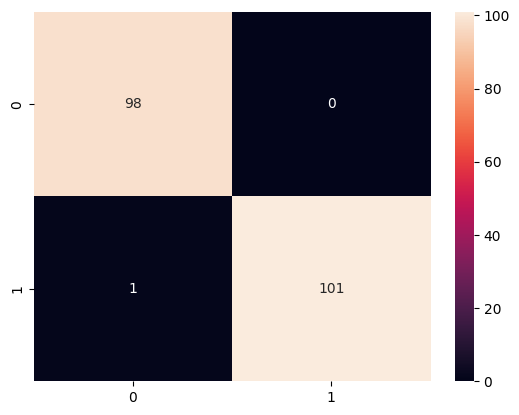

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred) * 100)

Accuracy: 99.5


In [ ]:
importance = rf.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

imp_df = imp_df.sort_values(by='Importance', ascending=False)

print(imp_df)

                      Feature  Importance
13  Course_Completion_Rate(%)    0.825346
0                  Student_ID    0.024309
9             Enrollment_Date    0.023034
10       Daily_Learning_Hours    0.020755
11          Quizzes_Attempted    0.016017
2                         Age    0.015751
1                     Country    0.013832
12      Assignments_Submitted    0.013296
5              Field_of_Study    0.008986
6               Platform_Used    0.008657
14    Satisfaction_Score(1-5)    0.007069
7                 Device_Used    0.006306
4             Education_Level    0.006028
3                      Gender    0.005851
8               Learning_Mode    0.004764


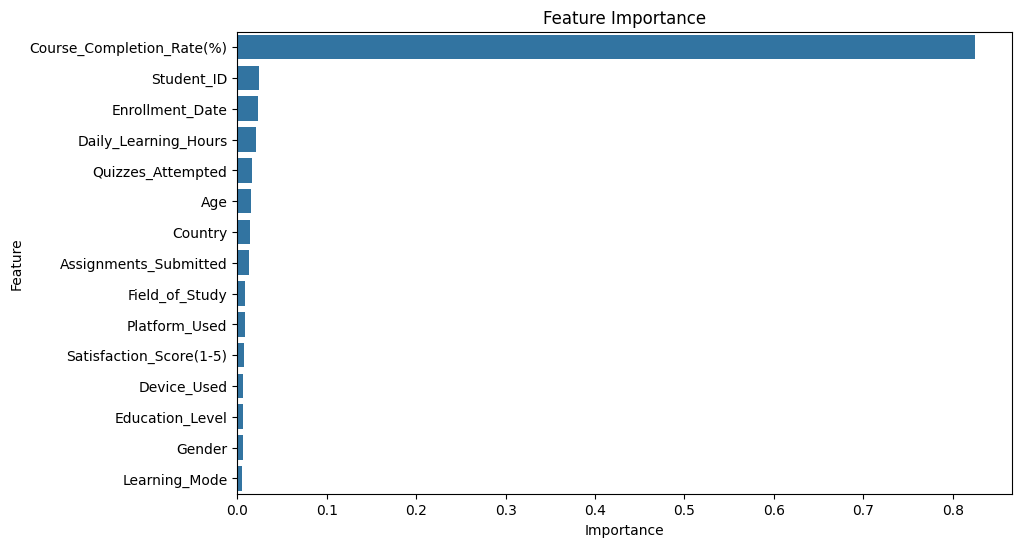

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=imp_df
)

plt.title("Feature Importance")
plt.show()